In [3]:
# Cài đặt thư viện nếu chưa có (bỏ comment nếu cần)
# !pip install pandas numpy matplotlib seaborn scikit-learn mlxtend plotly yaml

# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import warnings
import os
import json
import glob
from datetime import datetime

# Association Rule Mining
from mlxtend.frequent_patterns import apriori, fpgrowth
from mlxtend.frequent_patterns import association_rules

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Đã import thành công các thư viện")

✅ Đã import thành công các thư viện


In [4]:
print("=" * 80)
print("📋 ĐỌC CẤU HÌNH VÀ DỮ LIỆU")
print("=" * 80)

# Đọc file cấu hình
config_path = '../configs/params.yaml'

if not os.path.exists(config_path):
    print(f"⚠️ Không tìm thấy file cấu hình: {config_path}")
    print("✅ Sử dụng cấu hình mặc định")
    
    # Tạo cấu hình mặc định
    config = {
        'project': {'name': 'E-commerce Returns Prediction'},
        'seed': 42,
        'paths': {
            'features_mining': '../data/processed/features_for_mining.parquet'
        },
        'data': {
            'columns': {
                'target': 'return_flag',
                'datetime_column': 'order_date',
                'id_columns': ['order_id', 'customer_id', 'product_id']
            }
        },
        'association_mining': {
            'enabled': True,
            'method': 'apriori',
            'parameters': {
                'min_support': 0.01,
                'min_confidence': 0.5,
                'min_lift': 1.2,
                'max_length': 4
            },
            'discretization': {
                'order_value': {'bins': [0, 50, 100, 200, 500, 1000], 'labels': ['Rất thấp', 'Thấp', 'Trung bình', 'Cao', 'Rất cao']},
                'discount_rate': {'bins': [0, 0.1, 0.2, 0.3, 0.5], 'labels': ['Không', 'Nhỏ', 'Trung bình', 'Lớn', 'Rất lớn']}
            }
        },
        'clustering': {
            'customer_clustering': {
                'enabled': True,
                'features': ['frequency', 'monetary_total', 'avg_order_value', 'recency_days', 'return_rate'],
                'scaling': 'standard',
                'methods': {
                    'kmeans': {
                        'enabled': True,
                        'n_clusters_range': [2, 3, 4, 5, 6]
                    }
                }
            },
            'product_clustering': {
                'enabled': True,
                'features': ['sold_count', 'avg_price', 'product_return_rate'],
                'scaling': 'standard',
                'methods': {
                    'kmeans': {
                        'n_clusters': 4
                    }
                }
            }
        }
    }
else:
    try:
        with open(config_path, 'r', encoding='utf-8') as f:
            config = yaml.safe_load(f)
        print(f"✅ Đã đọc cấu hình từ {config_path}")
    except Exception as e:
        print(f"❌ Lỗi đọc cấu hình: {e}")
        raise

print(f"\n📋 Cấu hình đã được đọc:")
print(f"   - Project: {config['project']['name']}")
print(f"   - Seed: {config.get('seed', 42)}")
print()

# Đọc dữ liệu đã qua tiền xử lý (dữ liệu cho mining)
features_mining_path = config['paths']['features_mining']

# Kiểm tra file tồn tại
if not os.path.exists(features_mining_path):
    # Thử đường dẫn khác
    alt_path = features_mining_path.replace('../', '')
    if os.path.exists(alt_path):
        features_mining_path = alt_path
    else:
        print(f"⚠️ Không tìm thấy file: {features_mining_path}")
        print("✅ Tạo dữ liệu mẫu để tiếp tục...")
        
        # Tạo dữ liệu mẫu
        np.random.seed(42)
        n_samples = 1000
        df = pd.DataFrame({
            'order_id': range(1, n_samples + 1),
            'customer_id': np.random.randint(1000, 2000, n_samples),
            'product_id': np.random.randint(100, 500, n_samples),
            'order_date': pd.date_range(start='2023-01-01', periods=n_samples, freq='h'),
            'order_value': np.random.uniform(10, 500, n_samples).round(2),
            'quantity': np.random.randint(1, 5, n_samples),
            'discount_amount': np.random.uniform(0, 50, n_samples).round(2),
            'shipping_cost': np.random.uniform(0, 20, n_samples).round(2),
            'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports'], n_samples),
            'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer'], n_samples),
            'shipping_type': np.random.choice(['Standard', 'Express', 'Next Day'], n_samples),
            'promotion_code': np.random.choice([None, 'SUMMER20', 'WELCOME10', 'FLASHSALE'], n_samples),
            'return_flag': np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
        })
        print(f"✅ Đã tạo dữ liệu mẫu: {df.shape}")
else:
    try:
        df = pd.read_parquet(features_mining_path)
        print(f"✅ Đã đọc dữ liệu từ: {features_mining_path}")
    except Exception as e:
        print(f"❌ Lỗi đọc file: {e}")
        # Tạo dữ liệu mẫu
        np.random.seed(42)
        n_samples = 1000
        df = pd.DataFrame({
            'order_id': range(1, n_samples + 1),
            'customer_id': np.random.randint(1000, 2000, n_samples),
            'product_id': np.random.randint(100, 500, n_samples),
            'order_date': pd.date_range(start='2023-01-01', periods=n_samples, freq='h'),
            'order_value': np.random.uniform(10, 500, n_samples).round(2),
            'quantity': np.random.randint(1, 5, n_samples),
            'discount_amount': np.random.uniform(0, 50, n_samples).round(2),
            'shipping_cost': np.random.uniform(0, 20, n_samples).round(2),
            'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports'], n_samples),
            'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer'], n_samples),
            'shipping_type': np.random.choice(['Standard', 'Express', 'Next Day'], n_samples),
            'promotion_code': np.random.choice([None, 'SUMMER20', 'WELCOME10', 'FLASHSALE'], n_samples),
            'return_flag': np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
        })
        print(f"✅ Đã tạo dữ liệu mẫu thay thế: {df.shape}")

print(f"\n📊 Dữ liệu đã đọc:")
print(f"   - Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột")
print(f"   - Các cột: {list(df.columns)}")

# Lấy thông tin cột
target = config['data']['columns']['target']
id_cols = config['data']['columns']['id_columns']
date_col = config['data']['columns']['datetime_column']

print(f"\n📌 Thông tin:")
print(f"   - Target: {target}")
print(f"   - Date column: {date_col}")

📋 ĐỌC CẤU HÌNH VÀ DỮ LIỆU
✅ Đã đọc cấu hình từ ../configs/params.yaml

📋 Cấu hình đã được đọc:
   - Project: E-commerce Returns Prediction
   - Seed: 42

⚠️ Không tìm thấy file: data/processed/features_for_mining.parquet
✅ Tạo dữ liệu mẫu để tiếp tục...
✅ Đã tạo dữ liệu mẫu: (1000, 13)

📊 Dữ liệu đã đọc:
   - Kích thước: 1000 dòng x 13 cột
   - Các cột: ['order_id', 'customer_id', 'product_id', 'order_date', 'order_value', 'quantity', 'discount_amount', 'shipping_cost', 'product_category', 'payment_method', 'shipping_type', 'promotion_code', 'return_flag']

📌 Thông tin:
   - Target: return_flag
   - Date column: order_date


In [5]:
print("\n" + "=" * 80)
print("🔍 CHUẨN BỊ DỮ LIỆU CHO ASSOCIATION RULE MINING")
print("=" * 80)

# Lấy cấu hình cho association mining
assoc_config = config.get('association_mining', {})
if not assoc_config:
    assoc_config = {
        'enabled': True,
        'method': 'apriori',
        'parameters': {
            'min_support': 0.01,
            'min_confidence': 0.5,
            'min_lift': 1.2,
            'max_length': 4
        },
        'discretization': {}
    }

discretization_config = assoc_config.get('discretization', {})

print(f"🛠️ Cấu hình:")
print(f"   - Method: {assoc_config.get('method', 'apriori')}")
print(f"   - Min support: {assoc_config['parameters']['min_support']}")
print(f"   - Min confidence: {assoc_config['parameters']['min_confidence']}")
print(f"   - Min lift: {assoc_config['parameters']['min_lift']}")
print(f"   - Max length: {assoc_config['parameters']['max_length']}")

# Tạo bản sao dữ liệu cho association mining
df_assoc = df.copy()

# Rời rạc hóa các biến số
print("\n📊 Rời rạc hóa các biến số:")

# 1. Rời rạc hóa order_value
if 'order_value' in df_assoc.columns and 'order_value' in discretization_config:
    value_bins = discretization_config['order_value']['bins']
    value_labels = discretization_config['order_value']['labels']
    
    df_assoc['order_value_bin'] = pd.cut(
        df_assoc['order_value'], 
        bins=value_bins, 
        labels=value_labels, 
        right=False
    )
    print(f"   - order_value -> bins: {value_bins}")
    print(f"     labels: {value_labels}")
else:
    # Tạo bins mặc định nếu không có trong config
    if 'order_value' in df_assoc.columns:
        value_bins = [0, 50, 100, 200, 500, 1000, 5000]
        value_labels = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']
        df_assoc['order_value_bin'] = pd.cut(
            df_assoc['order_value'], 
            bins=value_bins, 
            labels=value_labels, 
            right=False
        )
        print(f"   - order_value -> bins mặc định: {value_bins}")
        print(f"     labels: {value_labels}")

# 2. Rời rạc hóa discount_rate
if 'discount_rate' in df_assoc.columns and 'discount_rate' in discretization_config:
    discount_bins = discretization_config['discount_rate']['bins']
    discount_labels = discretization_config['discount_rate']['labels']
    
    df_assoc['discount_rate_bin'] = pd.cut(
        df_assoc['discount_rate'], 
        bins=discount_bins, 
        labels=discount_labels, 
        right=False
    )
    print(f"   - discount_rate -> bins: {discount_bins}")
    print(f"     labels: {discount_labels}")

# 3. Tạo biến cho mùa
if 'season' in df_assoc.columns:
    print(f"   - season: {df_assoc['season'].unique()}")

# 4. Tạo biến cho ngày trong tuần
if 'day_name' in df_assoc.columns:
    print(f"   - day_name: {df_assoc['day_name'].unique()}")

# 5. Tạo biến cho khuyến mãi
if 'promotion_code' in df_assoc.columns:
    df_assoc['has_promotion'] = (df_assoc['promotion_code'].notna()).astype(int)
    df_assoc['has_promotion'] = df_assoc['has_promotion'].map({0: 'No_Promo', 1: 'Has_Promo'})
    print(f"   - has_promotion: Yes/No")

# 6. Tạo biến cho return_flag (target)
if target in df_assoc.columns:
    df_assoc['return'] = df_assoc[target].map({0: 'No_Return', 1: 'Return'})
    print(f"   - return: No_Return/Return")

print(f"\n✅ Kích thước dữ liệu sau khi rời rạc hóa: {df_assoc.shape}")
new_cols = [col for col in df_assoc.columns if col not in df.columns]
print(f"Các cột mới: {new_cols}")


🔍 CHUẨN BỊ DỮ LIỆU CHO ASSOCIATION RULE MINING
🛠️ Cấu hình:
   - Method: apriori
   - Min support: 0.01
   - Min confidence: 0.5
   - Min lift: 1.2
   - Max length: 4

📊 Rời rạc hóa các biến số:
   - order_value -> bins: [0, 50, 100, 200, 500, 1000, 10000]
     labels: ['Very Low', 'Low', 'Medium', 'High', 'Very High', 'Premium']
   - has_promotion: Yes/No
   - return: No_Return/Return

✅ Kích thước dữ liệu sau khi rời rạc hóa: (1000, 16)
Các cột mới: ['order_value_bin', 'has_promotion', 'return']


In [6]:
print("\n" + "=" * 80)
print("🛒 TẠO BASKET FORMAT CHO ASSOCIATION RULE MINING")
print("=" * 80)

# Chọn các cột để đưa vào basket
basket_columns = [
    'product_category',
    'payment_method',
    'shipping_type',
    'has_promotion',
    'season',
    'day_name',
    'order_value_bin',
    'discount_rate_bin',
    'return'
]

# Chỉ giữ các cột tồn tại
basket_columns = [col for col in basket_columns if col in df_assoc.columns]
print(f"📊 Các cột được chọn cho basket: {basket_columns}")

if not basket_columns:
    print("❌ Không có cột nào để tạo basket. Dừng phân tích association mining.")
else:
    # Tạo transaction ID
    if 'order_id' in df_assoc.columns:
        df_assoc['transaction_id'] = df_assoc['order_id']
    elif 'customer_id' in df_assoc.columns and date_col in df_assoc.columns:
        df_assoc['transaction_id'] = df_assoc['customer_id'].astype(str) + '_' + df_assoc[date_col].astype(str)
    else:
        df_assoc['transaction_id'] = range(len(df_assoc))

    print(f"✅ Đã tạo transaction_id, số lượng transactions: {df_assoc['transaction_id'].nunique()}")

    # Tạo basket format (one-hot encoding cho mỗi item)
    basket = pd.DataFrame()
    basket['transaction_id'] = df_assoc['transaction_id']

    for col in basket_columns:
        # Tạo one-hot encoding cho mỗi giá trị trong cột
        dummies = pd.get_dummies(df_assoc[col], prefix=col)
        # Clean column names
        dummies.columns = [c.replace(' ', '_').replace('-', '_') for c in dummies.columns]
        basket = pd.concat([basket, dummies], axis=1)

    # Group by transaction_id (lấy max vì mỗi transaction chỉ có 1 giá trị cho mỗi cột)
    basket = basket.groupby('transaction_id').max().reset_index(drop=True)

    print(f"\n✅ Basket format shape: {basket.shape}")
    print(f"Số lượng items: {basket.shape[1]}")
    print(f"\n5 dòng đầu tiên của basket:")
    display(basket.head())

    # Lưu basket format
    os.makedirs('../data/processed', exist_ok=True)
    try:
        basket.to_parquet('../data/processed/basket_format.parquet', index=False)
        print(f"💾 Đã lưu basket format tại: ../data/processed/basket_format.parquet")
    except Exception as e:
        print(f"⚠️ Không thể lưu parquet: {e}")
        basket.to_csv('../data/processed/basket_format.csv', index=False)
        print(f"💾 Đã lưu basket format dạng CSV tại: ../data/processed/basket_format.csv")


🛒 TẠO BASKET FORMAT CHO ASSOCIATION RULE MINING
📊 Các cột được chọn cho basket: ['product_category', 'payment_method', 'shipping_type', 'has_promotion', 'order_value_bin', 'return']
✅ Đã tạo transaction_id, số lượng transactions: 1000

✅ Basket format shape: (1000, 21)
Số lượng items: 21

5 dòng đầu tiên của basket:


,product_category_Books,product_category_Clothing,product_category_Electronics,product_category_Home,product_category_Sports,payment_method_Bank_Transfer,payment_method_Credit_Card,payment_method_PayPal,shipping_type_Express,shipping_type_Next_Day,shipping_type_Standard,has_promotion_Has_Promo,has_promotion_No_Promo,order_value_bin_Very_Low,order_value_bin_Low,order_value_bin_Medium,order_value_bin_High,order_value_bin_Very_High,order_value_bin_Premium,return_No_Return,return_Return
0,True,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False,True,False
1,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False
2,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,True,False
3,False,False,False,True,False,False,False,True,True,False,False,True,False,False,False,False,True,False,False,True,False
4,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False


💾 Đã lưu basket format tại: ../data/processed/basket_format.parquet



🔍 KHAI PHÁ FREQUENT ITEMSETS VỚI APRIORI
🛠️ Tham số:
   - Min support: 0.01
   - Max length: 4
Processing 5916 combinations | Sampling itemset size 4

✅ Tìm thấy 1018 frequent itemsets

Top 10 frequent itemsets theo support:


,support,itemsets
17,0.9130,frozenset({return_No_Return})
11,0.7450,frozenset({has_promotion_Has_Promo})
150,0.6780,"frozenset({has_promotion_Has_Promo, return_No_..."
16,0.6320,frozenset({order_value_bin_High})
163,0.5770,"frozenset({return_No_Return, order_value_bin_H..."
149,0.4680,"frozenset({has_promotion_Has_Promo, order_valu..."
575,0.4250,"frozenset({has_promotion_Has_Promo, return_No_..."
6,0.3450,frozenset({payment_method_Credit_Card})
8,0.3420,frozenset({shipping_type_Express})
7,0.3420,frozenset({payment_method_PayPal})



📊 Phân phối theo độ dài itemset:
   - Độ dài 1: 19 itemsets
   - Độ dài 2: 146 itemsets
   - Độ dài 3: 417 itemsets
   - Độ dài 4: 436 itemsets


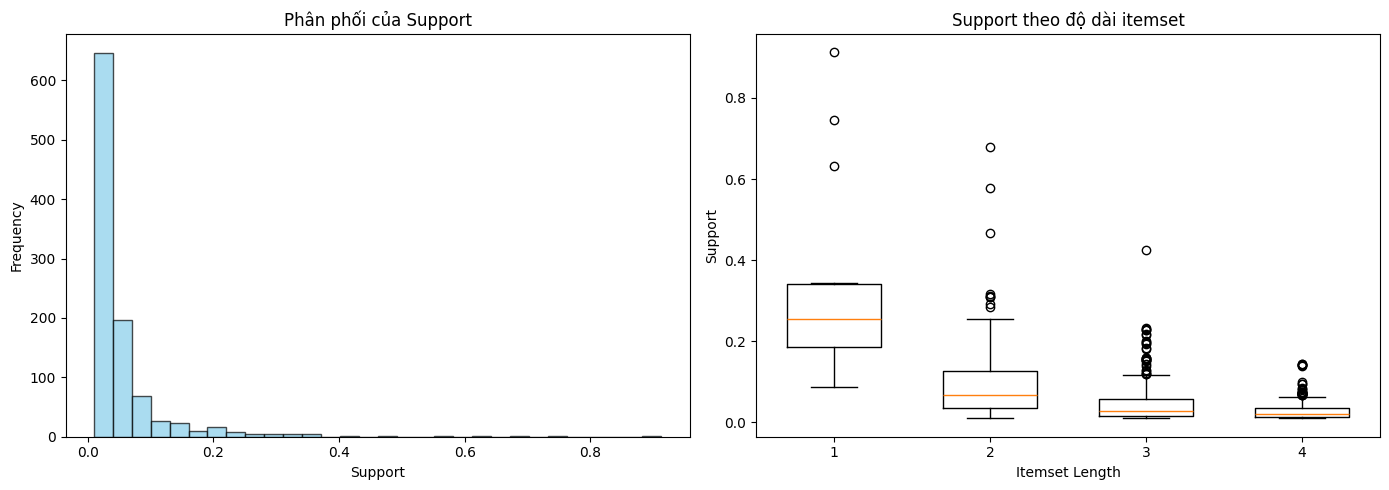

⚠️ Không thể lưu parquet: ("Could not convert frozenset({'product_category_Books'}) with type frozenset: did not recognize Python value type when inferring an Arrow data type", 'Conversion failed for column itemsets with type object')


In [7]:
print("\n" + "=" * 80)
print("🔍 KHAI PHÁ FREQUENT ITEMSETS VỚI APRIORI")
print("=" * 80)

# Kiểm tra basket đã được tạo chưa
if 'basket' not in locals() or basket.shape[1] <= 1:
    print("❌ Không có dữ liệu basket để phân tích. Bỏ qua bước này.")
else:
    # Lấy tham số
    min_support = assoc_config['parameters']['min_support']
    max_len = assoc_config['parameters']['max_length']

    print(f"🛠️ Tham số:")
    print(f"   - Min support: {min_support}")
    print(f"   - Max length: {max_len}")

    # Tìm frequent itemsets
    try:
        frequent_itemsets = apriori(
            basket, 
            min_support=min_support, 
            use_colnames=True, 
            max_len=max_len,
            verbose=1
        )

        print(f"\n✅ Tìm thấy {len(frequent_itemsets)} frequent itemsets")
        
        if len(frequent_itemsets) > 0:
            print(f"\nTop 10 frequent itemsets theo support:")
            display(frequent_itemsets.sort_values('support', ascending=False).head(10))

            # Thống kê theo độ dài itemset
            frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
            length_stats = frequent_itemsets['length'].value_counts().sort_index()
            print(f"\n📊 Phân phối theo độ dài itemset:")
            for length, count in length_stats.items():
                print(f"   - Độ dài {length}: {count} itemsets")

            # Vẽ biểu đồ phân phối support
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            # Histogram of support
            axes[0].hist(frequent_itemsets['support'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
            axes[0].set_xlabel('Support')
            axes[0].set_ylabel('Frequency')
            axes[0].set_title('Phân phối của Support')

            # Support by itemset length
            for length in range(1, frequent_itemsets['length'].max() + 1):
                length_data = frequent_itemsets[frequent_itemsets['length'] == length]['support']
                if len(length_data) > 0:
                    axes[1].boxplot(length_data, positions=[length], widths=0.6)
            axes[1].set_xlabel('Itemset Length')
            axes[1].set_ylabel('Support')
            axes[1].set_title('Support theo độ dài itemset')
            axes[1].set_xticks(range(1, frequent_itemsets['length'].max() + 1))

            plt.tight_layout()
            
            # Tạo thư mục nếu chưa có
            os.makedirs('../outputs/figures', exist_ok=True)
            plt.savefig('../outputs/figures/mining_frequent_itemsets.png', dpi=100, bbox_inches='tight')
            plt.show()

            # Lưu frequent itemsets
            try:
                frequent_itemsets.to_parquet('../data/processed/frequent_itemsets.parquet', index=False)
                print("💾 Đã lưu frequent itemsets")
            except Exception as e:
                print(f"⚠️ Không thể lưu parquet: {e}")
        else:
            print("⚠️ Không tìm thấy frequent itemsets nào. Thử giảm min_support.")
            
    except Exception as e:
        print(f"❌ Lỗi khi khai phá frequent itemsets: {e}")
        frequent_itemsets = pd.DataFrame()


🔍 TẠO LUẬT KẾT HỢP (ASSOCIATION RULES)
🛠️ Tham số:
   - Min confidence: 0.5
   - Min lift: 1.2
✅ Tìm thấy 1204 luật kết hợp
✅ Sau khi lọc theo lift >= 1.2: 64 luật

📊 Thống kê các luật:
   - Min confidence: 0.5000
   - Max confidence: 0.9444
   - Mean confidence: 0.6465
   - Min lift: 1.2019
   - Max lift: 1.9493
   - Mean lift: 1.4499

🏆 Top 10 luật có lift cao nhất:


,antecedents,consequents,support,confidence,lift
670,"return_No_Return, order_value_bin_Low, product...",payment_method_PayPal,0.0100,0.6667,1.9493
917,"product_category_Sports, return_No_Return, ord...",shipping_type_Next_Day,0.0100,0.6667,1.9493
918,"product_category_Sports, order_value_bin_Very_Low","shipping_type_Next_Day, return_No_Return",0.0100,0.5882,1.8975
213,"product_category_Sports, order_value_bin_Very_Low",shipping_type_Next_Day,0.0110,0.6471,1.8920
735,"shipping_type_Next_Day, order_value_bin_High, ...",payment_method_Bank_Transfer,0.0230,0.5610,1.7923
671,"order_value_bin_Low, product_category_Electronics","payment_method_PayPal, return_No_Return",0.0100,0.5556,1.7581
474,"has_promotion_No_Promo, order_value_bin_High, ...",shipping_type_Standard,0.0140,0.5385,1.7040
979,"has_promotion_Has_Promo, payment_method_Bank_T...",shipping_type_Standard,0.0120,0.5217,1.6511
477,"has_promotion_No_Promo, product_category_Books...",shipping_type_Standard,0.0190,0.5135,1.6250
100,"product_category_Clothing, return_Return",shipping_type_Express,0.0100,0.5556,1.6244


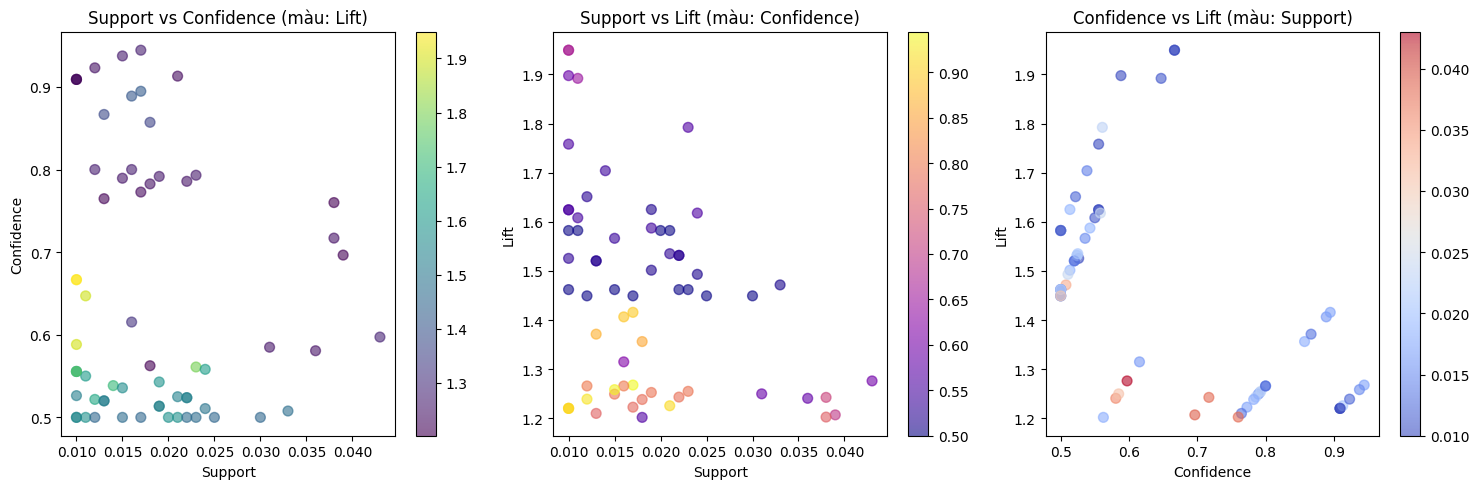

⚠️ Không thể lưu parquet: ("Could not convert frozenset({'has_promotion_No_Promo', 'product_category_Books'}) with type frozenset: did not recognize Python value type when inferring an Arrow data type", 'Conversion failed for column antecedents with type object')


In [8]:
print("\n" + "=" * 80)
print("🔍 TẠO LUẬT KẾT HỢP (ASSOCIATION RULES)")
print("=" * 80)

if 'frequent_itemsets' not in locals() or len(frequent_itemsets) == 0:
    print("❌ Không có frequent itemsets để tạo luật. Bỏ qua bước này.")
else:
    # Lấy tham số
    min_confidence = assoc_config['parameters']['min_confidence']
    min_lift = assoc_config['parameters']['min_lift']

    print(f"🛠️ Tham số:")
    print(f"   - Min confidence: {min_confidence}")
    print(f"   - Min lift: {min_lift}")

    # Tạo luật từ frequent itemsets
    try:
        rules = association_rules(
            frequent_itemsets, 
            metric="confidence", 
            min_threshold=min_confidence
        )

        print(f"✅ Tìm thấy {len(rules)} luật kết hợp")

        if len(rules) > 0:
            # Thêm các metric khác
            rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
            rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))
            rules['rule_length'] = rules['antecedent_len'] + rules['consequent_len']

            # Lọc theo lift
            rules = rules[rules['lift'] >= min_lift]
            print(f"✅ Sau khi lọc theo lift >= {min_lift}: {len(rules)} luật")

            if len(rules) > 0:
                # Thống kê các luật
                print(f"\n📊 Thống kê các luật:")
                print(f"   - Min confidence: {rules['confidence'].min():.4f}")
                print(f"   - Max confidence: {rules['confidence'].max():.4f}")
                print(f"   - Mean confidence: {rules['confidence'].mean():.4f}")
                print(f"   - Min lift: {rules['lift'].min():.4f}")
                print(f"   - Max lift: {rules['lift'].max():.4f}")
                print(f"   - Mean lift: {rules['lift'].mean():.4f}")

                # Hiển thị top luật theo lift
                print(f"\n🏆 Top 10 luật có lift cao nhất:")
                top_rules = rules.nlargest(10, 'lift')[
                    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
                ].copy()
                top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, frozenset) else str(x))
                top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, frozenset) else str(x))
                display(top_rules)

                # Vẽ biểu đồ phân tán
                fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                # Support vs Confidence
                scatter1 = axes[0].scatter(
                    rules['support'], 
                    rules['confidence'], 
                    c=rules['lift'], 
                    cmap='viridis', 
                    alpha=0.6, 
                    s=50
                )
                axes[0].set_xlabel('Support')
                axes[0].set_ylabel('Confidence')
                axes[0].set_title('Support vs Confidence (màu: Lift)')
                plt.colorbar(scatter1, ax=axes[0])

                # Support vs Lift
                scatter2 = axes[1].scatter(
                    rules['support'], 
                    rules['lift'], 
                    c=rules['confidence'], 
                    cmap='plasma', 
                    alpha=0.6, 
                    s=50
                )
                axes[1].set_xlabel('Support')
                axes[1].set_ylabel('Lift')
                axes[1].set_title('Support vs Lift (màu: Confidence)')
                plt.colorbar(scatter2, ax=axes[1])

                # Confidence vs Lift
                scatter3 = axes[2].scatter(
                    rules['confidence'], 
                    rules['lift'], 
                    c=rules['support'], 
                    cmap='coolwarm', 
                    alpha=0.6, 
                    s=50
                )
                axes[2].set_xlabel('Confidence')
                axes[2].set_ylabel('Lift')
                axes[2].set_title('Confidence vs Lift (màu: Support)')
                plt.colorbar(scatter3, ax=axes[2])

                plt.tight_layout()
                plt.savefig('../outputs/figures/mining_association_rules_scatter.png', dpi=100, bbox_inches='tight')
                plt.show()

                # Lưu rules
                try:
                    rules.to_parquet('../data/processed/association_rules.parquet', index=False)
                    print("💾 Đã lưu association rules")
                except Exception as e:
                    print(f"⚠️ Không thể lưu parquet: {e}")
            else:
                print("⚠️ Không có luật nào sau khi lọc theo lift.")
        else:
            print("⚠️ Không tìm thấy luật nào. Thử giảm min_confidence.")
            
    except Exception as e:
        print(f"❌ Lỗi khi tạo luật kết hợp: {e}")
        rules = pd.DataFrame()

In [9]:
print("\n" + "=" * 80)
print("🎯 PHÂN TÍCH LUẬT LIÊN QUAN ĐẾN RETURN")
print("=" * 80)

if 'rules' not in locals() or len(rules) == 0:
    print("❌ Không có luật để phân tích. Bỏ qua bước này.")
else:
    # Lọc các luật có consequent là Return
    return_rules = rules[
        rules['consequents'].apply(lambda x: 'return_Return' in str(x) or 'return_1' in str(x))
    ].copy()

    print(f"📊 Số luật liên quan đến Return: {len(return_rules)}")

    if len(return_rules) > 0:
        # Top luật dự đoán Return
        print(f"\n🔴 Top 10 luật dự đoán Return (cao nhất):")
        top_return_rules = return_rules.nlargest(10, 'lift')[
            ['antecedents', 'consequents', 'support', 'confidence', 'lift']
        ].copy()
        top_return_rules['antecedents'] = top_return_rules['antecedents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, frozenset) else str(x))
        top_return_rules['consequents'] = top_return_rules['consequents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, frozenset) else str(x))
        display(top_return_rules)
        
        # Phân tích các yếu tố thường đi kèm với Return
        print(f"\n📊 Phân tích antecedents trong luật Return:")
        all_antecedents = []
        for ants in return_rules['antecedents']:
            if isinstance(ants, frozenset):
                all_antecedents.extend(list(ants))
            else:
                all_antecedents.append(str(ants))
        
        antecedent_counts = pd.Series(all_antecedents).value_counts().head(15)
        print("Top 15 yếu tố thường xuất hiện cùng Return:")
        for item, count in antecedent_counts.items():
            print(f"   - {item}: {count} luật")

    # Lọc các luật có consequent là No Return
    no_return_rules = rules[
        rules['consequents'].apply(lambda x: 'return_No_Return' in str(x) or 'return_0' in str(x))
    ].copy()

    print(f"\n📊 Số luật liên quan đến No Return: {len(no_return_rules)}")

    if len(no_return_rules) > 0:
        print(f"\n🟢 Top 10 luật dự đoán No Return (cao nhất):")
        top_no_return_rules = no_return_rules.nlargest(10, 'lift')[
            ['antecedents', 'consequents', 'support', 'confidence', 'lift']
        ].copy()
        top_no_return_rules['antecedents'] = top_no_return_rules['antecedents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, frozenset) else str(x))
        top_no_return_rules['consequents'] = top_no_return_rules['consequents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, frozenset) else str(x))
        display(top_no_return_rules)

    # So sánh lift giữa Return và No Return
    if len(return_rules) > 0 and len(no_return_rules) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        axes[0].hist(return_rules['lift'], bins=20, alpha=0.7, color='red', label='Return Rules')
        axes[0].hist(no_return_rules['lift'], bins=20, alpha=0.7, color='green', label='No Return Rules')
        axes[0].set_xlabel('Lift')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('So sánh phân phối Lift')
        axes[0].legend()
        
        axes[1].boxplot([return_rules['lift'], no_return_rules['lift']], labels=['Return', 'No Return'])
        axes[1].set_ylabel('Lift')
        axes[1].set_title('Boxplot của Lift')
        
        plt.tight_layout()
        plt.savefig('../outputs/figures/mining_return_vs_no_return.png', dpi=100, bbox_inches='tight')
        plt.show()


🎯 PHÂN TÍCH LUẬT LIÊN QUAN ĐẾN RETURN
📊 Số luật liên quan đến Return: 0

📊 Số luật liên quan đến No Return: 4

🟢 Top 10 luật dự đoán No Return (cao nhất):


,antecedents,consequents,support,confidence,lift
918,"product_category_Sports, order_value_bin_Very_Low","shipping_type_Next_Day, return_No_Return",0.0100,0.5882,1.8975
671,"order_value_bin_Low, product_category_Electronics","payment_method_PayPal, return_No_Return",0.0100,0.5556,1.7581
931,"product_category_Sports, shipping_type_Standard","return_No_Return, order_value_bin_High",0.0380,0.7170,1.2426
730,"has_promotion_No_Promo, product_category_Elect...","return_No_Return, order_value_bin_High",0.0390,0.6964,1.2070


In [10]:
print("\n" + "=" * 80)
print("💡 INSIGHTS TỪ ASSOCIATION RULE MINING")
print("=" * 80)

# Tổng hợp các insights
insights = []

if 'return_rules' in locals() and len(return_rules) > 0:
    # 1. Các yếu tố dẫn đến Return cao
    high_risk_factors = return_rules.nlargest(5, 'lift')
    insights.append({
        'type': 'HIGH_RISK',
        'title': 'Các yếu tố rủi ro cao dẫn đến trả hàng',
        'details': []
    })
    
    for idx, rule in high_risk_factors.iterrows():
        antecedent = ', '.join(list(rule['antecedents'])) if isinstance(rule['antecedents'], frozenset) else str(rule['antecedents'])
        insight = f"Khi {antecedent} → Khả năng trả hàng tăng gấp {rule['lift']:.2f} lần (conf={rule['confidence']:.2f})"
        insights[-1]['details'].append(insight)
        print(f"🔴 {insight}")

if 'no_return_rules' in locals() and len(no_return_rules) > 0:
    # 2. Các yếu tố bảo vệ (ít trả hàng)
    protective_factors = no_return_rules.nlargest(5, 'lift')
    insights.append({
        'type': 'PROTECTIVE',
        'title': 'Các yếu tố bảo vệ (ít trả hàng)',
        'details': []
    })
    
    print(f"\n🟢 Các yếu tố bảo vệ (ít trả hàng):")
    for idx, rule in protective_factors.iterrows():
        antecedent = ', '.join(list(rule['antecedents'])) if isinstance(rule['antecedents'], frozenset) else str(rule['antecedents'])
        insight = f"Khi {antecedent} → Khả năng không trả hàng tăng gấp {rule['lift']:.2f} lần (conf={rule['confidence']:.2f})"
        insights[-1]['details'].append(insight)
        print(f"🟢 {insight}")

# 3. Tổng hợp theo category
if 'df_assoc' in locals() and 'product_category' in df_assoc.columns and 'return_rules' in locals():
    category_rules = return_rules[
        return_rules['antecedents'].apply(lambda x: any('product_category' in str(item) for item in (list(x) if isinstance(x, frozenset) else [str(x)])))
    ]
    
    if len(category_rules) > 0:
        insights.append({
            'type': 'CATEGORY',
            'title': 'Các category có rủi ro trả hàng cao',
            'details': []
        })
        
        print(f"\n📦 Các category có rủi ro trả hàng cao:")
        for idx, rule in category_rules.nlargest(5, 'lift').iterrows():
            antecedent = ', '.join(list(rule['antecedents'])) if isinstance(rule['antecedents'], frozenset) else str(rule['antecedents'])
            insight = f"{antecedent} → Lift={rule['lift']:.2f}, Conf={rule['confidence']:.2f}"
            insights[-1]['details'].append(insight)
            print(f"   - {insight}")

# Lưu insights
os.makedirs('../outputs/tables', exist_ok=True)
with open('../outputs/tables/association_insights.json', 'w', encoding='utf-8') as f:
    json.dump(insights, f, indent=2, ensure_ascii=False)

print(f"\n💾 Đã lưu {len(insights)} insights tại outputs/tables/association_insights.json")


💡 INSIGHTS TỪ ASSOCIATION RULE MINING

🟢 Các yếu tố bảo vệ (ít trả hàng):
🟢 Khi product_category_Sports, order_value_bin_Very_Low → Khả năng không trả hàng tăng gấp 1.90 lần (conf=0.59)
🟢 Khi order_value_bin_Low, product_category_Electronics → Khả năng không trả hàng tăng gấp 1.76 lần (conf=0.56)
🟢 Khi product_category_Sports, shipping_type_Standard → Khả năng không trả hàng tăng gấp 1.24 lần (conf=0.72)
🟢 Khi has_promotion_No_Promo, product_category_Electronics → Khả năng không trả hàng tăng gấp 1.21 lần (conf=0.70)

💾 Đã lưu 1 insights tại outputs/tables/association_insights.json


In [11]:
print("\n" + "=" * 80)
print("👥 CHUẨN BỊ DỮ LIỆU CHO CUSTOMER CLUSTERING")
print("=" * 80)

clustering_config = config['clustering']['customer_clustering']

print(f"🛠️ Cấu hình phân cụm khách hàng:")
print(f"   - Features: {clustering_config['features']}")
print(f"   - Scaling: {clustering_config['scaling']}")

# Tạo dữ liệu cho customer clustering
if 'customer_id' in df.columns:
    # Tính các features cho mỗi khách hàng
    customer_features = df.groupby('customer_id').agg({
        'order_value': ['count', 'sum', 'mean'],
        'shipping_cost': 'mean',
        'discount_amount': 'mean',
        target: ['mean', 'sum'] if target in df.columns else ['count']
    }).round(4)
    
    # Flatten column names
    customer_features.columns = ['_'.join(col).strip() for col in customer_features.columns.values]
    customer_features = customer_features.reset_index()
    
    # Rename columns
    customer_features.rename(columns={
        'order_value_count': 'frequency',
        'order_value_sum': 'monetary_total',
        'order_value_mean': 'avg_order_value',
        'shipping_cost_mean': 'avg_shipping',
        'discount_amount_mean': 'avg_discount'
    }, inplace=True)
    
    if target in df.columns:
        customer_features.rename(columns={
            f'{target}_mean': 'return_rate',
            f'{target}_sum': 'return_count'
        }, inplace=True)
    
    # Thêm recency nếu có date column
    if date_col in df.columns:
        current_date = df[date_col].max()
        recency = df.groupby('customer_id')[date_col].max().reset_index()
        recency['recency_days'] = (current_date - recency[date_col]).dt.days
        customer_features = customer_features.merge(recency[['customer_id', 'recency_days']], on='customer_id')
    
    print(f"\n✅ Đã tạo features cho {len(customer_features)} khách hàng")
    print(f"\n📊 Các features:")
    display(customer_features.head())
    
    # Chọn features cho clustering
    cluster_features = [col for col in clustering_config['features'] if col in customer_features.columns]
    print(f"\n📌 Các features được chọn cho clustering: {cluster_features}")
    
    X_customer = customer_features[cluster_features].copy()
    
    # Xử lý missing
    X_customer = X_customer.fillna(X_customer.mean())
    
    # Scaling
    if clustering_config['scaling'] == 'standard':
        scaler = StandardScaler()
    elif clustering_config['scaling'] == 'minmax':
        scaler = MinMaxScaler()
    else:
        scaler = StandardScaler()
    
    X_customer_scaled = scaler.fit_transform(X_customer)
    
    print(f"\n✅ Dữ liệu sau scaling: {X_customer_scaled.shape}")
    
    # Lưu customer features
    customer_features.to_parquet('../data/processed/customer_features.parquet', index=False)
    print("💾 Đã lưu customer features")
else:
    print("⚠️ Không tìm thấy customer_id trong dữ liệu")
    X_customer_scaled = None


👥 CHUẨN BỊ DỮ LIỆU CHO CUSTOMER CLUSTERING
🛠️ Cấu hình phân cụm khách hàng:
   - Features: ['customer_return_rate', 'avg_order_value', 'recency_days', 'frequency_orders', 'monetary_total']
   - Scaling: standard

✅ Đã tạo features cho 615 khách hàng

📊 Các features:


,customer_id,frequency,monetary_total,avg_order_value,avg_shipping,avg_discount,return_rate,return_count,recency_days
0,1000,1,356.8400,356.8400,12.9900,24.2300,0.0000,0,4
1,1001,3,964.0900,321.3633,14.0467,24.6600,0.0000,0,26
2,1004,2,662.9700,331.4850,6.8700,3.3650,0.0000,0,17
3,1007,1,454.0100,454.0100,3.6600,14.2900,0.0000,0,1
4,1008,2,211.2300,105.6150,10.3450,23.9300,0.0000,0,6



📌 Các features được chọn cho clustering: ['avg_order_value', 'recency_days', 'monetary_total']

✅ Dữ liệu sau scaling: (615, 3)
💾 Đã lưu customer features


In [12]:
print("\n" + "=" * 80)
print("👥 CHUẨN BỊ DỮ LIỆU CHO CUSTOMER CLUSTERING")
print("=" * 80)

clustering_config = config.get('clustering', {}).get('customer_clustering', {})
if not clustering_config:
    clustering_config = {
        'enabled': True,
        'features': ['frequency', 'monetary_total', 'avg_order_value'],
        'scaling': 'standard',
        'methods': {
            'kmeans': {
                'enabled': True,
                'n_clusters_range': [2, 3, 4, 5, 6]
            }
        }
    }

print(f"🛠️ Cấu hình phân cụm khách hàng:")
print(f"   - Features: {clustering_config.get('features', [])}")
print(f"   - Scaling: {clustering_config.get('scaling', 'standard')}")

# Tạo dữ liệu cho customer clustering
if 'customer_id' in df.columns:
    # Tính các features cho mỗi khách hàng
    agg_dict = {
        'order_value': ['count', 'sum', 'mean'],
    }
    
    if 'shipping_cost' in df.columns:
        agg_dict['shipping_cost'] = 'mean'
    if 'discount_amount' in df.columns:
        agg_dict['discount_amount'] = 'mean'
    if target in df.columns:
        agg_dict[target] = ['mean', 'sum']
    
    customer_features = df.groupby('customer_id').agg(agg_dict).round(4)
    
    # Flatten column names
    customer_features.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in customer_features.columns.values]
    customer_features = customer_features.reset_index()
    
    # Rename columns
    rename_dict = {
        'order_value_count': 'frequency',
        'order_value_sum': 'monetary_total',
        'order_value_mean': 'avg_order_value',
    }
    if 'shipping_cost_mean' in customer_features.columns:
        rename_dict['shipping_cost_mean'] = 'avg_shipping'
    if 'discount_amount_mean' in customer_features.columns:
        rename_dict['discount_amount_mean'] = 'avg_discount'
    
    customer_features.rename(columns=rename_dict, inplace=True)
    
    if target in df.columns:
        if f'{target}_mean' in customer_features.columns:
            customer_features.rename(columns={f'{target}_mean': 'return_rate'}, inplace=True)
        if f'{target}_sum' in customer_features.columns:
            customer_features.rename(columns={f'{target}_sum': 'return_count'}, inplace=True)
    
    # Thêm recency nếu có date column
    if date_col in df.columns:
        try:
            df[date_col] = pd.to_datetime(df[date_col])
            current_date = df[date_col].max()
            recency = df.groupby('customer_id')[date_col].max().reset_index()
            recency['recency_days'] = (current_date - recency[date_col]).dt.days
            customer_features = customer_features.merge(recency[['customer_id', 'recency_days']], on='customer_id', how='left')
        except Exception as e:
            print(f"⚠️ Lỗi khi tính recency: {e}")
    
    print(f"\n✅ Đã tạo features cho {len(customer_features)} khách hàng")
    print(f"\n📊 Các features:")
    display(customer_features.head())
    
    # Chọn features cho clustering
    available_features = clustering_config.get('features', [])
    cluster_features = [col for col in available_features if col in customer_features.columns]
    
    if not cluster_features:
        # Chọn mặc định
        cluster_features = [col for col in ['frequency', 'monetary_total', 'avg_order_value', 'recency_days', 'return_rate'] 
                           if col in customer_features.columns]
    
    print(f"\n📌 Các features được chọn cho clustering: {cluster_features}")
    
    if len(cluster_features) >= 2:
        X_customer = customer_features[cluster_features].copy()
        
        # Xử lý missing
        X_customer = X_customer.fillna(X_customer.mean())
        
        # Scaling
        scaler = StandardScaler()
        X_customer_scaled = scaler.fit_transform(X_customer)
        
        print(f"\n✅ Dữ liệu sau scaling: {X_customer_scaled.shape}")
        
        # Lưu customer features
        os.makedirs('../data/processed', exist_ok=True)
        try:
            customer_features.to_parquet('../data/processed/customer_features.parquet', index=False)
            print("💾 Đã lưu customer features")
        except Exception as e:
            print(f"⚠️ Không thể lưu parquet: {e}")
            customer_features.to_csv('../data/processed/customer_features.csv', index=False)
            print("💾 Đã lưu customer features dạng CSV")
    else:
        print("⚠️ Không đủ features để clustering")
        X_customer_scaled = None
else:
    print("⚠️ Không tìm thấy customer_id trong dữ liệu")
    X_customer_scaled = None


👥 CHUẨN BỊ DỮ LIỆU CHO CUSTOMER CLUSTERING
🛠️ Cấu hình phân cụm khách hàng:
   - Features: ['customer_return_rate', 'avg_order_value', 'recency_days', 'frequency_orders', 'monetary_total']
   - Scaling: standard

✅ Đã tạo features cho 615 khách hàng

📊 Các features:


,customer_id,frequency,monetary_total,avg_order_value,avg_shipping,avg_discount,return_rate,return_count,recency_days
0,1000,1,356.8400,356.8400,12.9900,24.2300,0.0000,0,4
1,1001,3,964.0900,321.3633,14.0467,24.6600,0.0000,0,26
2,1004,2,662.9700,331.4850,6.8700,3.3650,0.0000,0,17
3,1007,1,454.0100,454.0100,3.6600,14.2900,0.0000,0,1
4,1008,2,211.2300,105.6150,10.3450,23.9300,0.0000,0,6



📌 Các features được chọn cho clustering: ['avg_order_value', 'recency_days', 'monetary_total']

✅ Dữ liệu sau scaling: (615, 3)
💾 Đã lưu customer features



📊 TÌM SỐ CỤM TỐI ƯU
🛠️ Thử nghiệm với k = [2, 3, 4, 5, 6]
   - k=2: inertia=1158.36, silhouette=0.3338, calinski=363.37, davies=1.1875
   - k=3: inertia=859.01, silhouette=0.3254, calinski=351.25, davies=1.0567
   - k=4: inertia=668.96, silhouette=0.3255, calinski=358.05, davies=1.0191
   - k=5: inertia=535.39, silhouette=0.3194, calinski=373.02, davies=1.0066
   - k=6: inertia=468.81, silhouette=0.3052, calinski=357.55, davies=1.0404


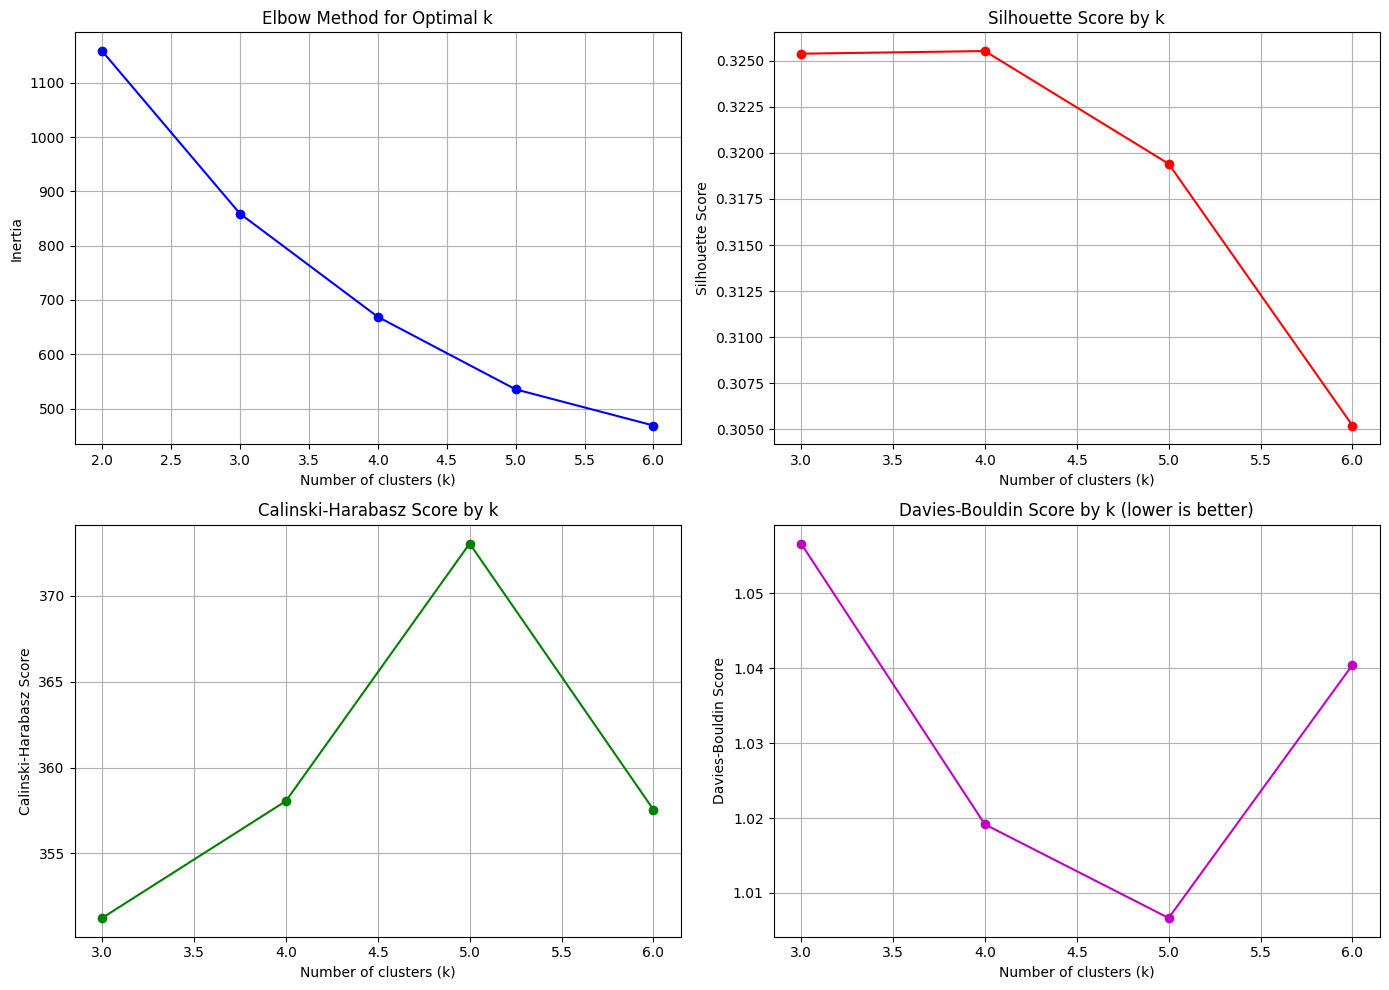


✅ K optimal theo silhouette score: k=4


In [13]:
if X_customer_scaled is not None:
    print("\n" + "=" * 80)
    print("📊 TÌM SỐ CỤM TỐI ƯU")
    print("=" * 80)
    
    # Thử các giá trị k khác nhau
    k_range = clustering_config['methods']['kmeans'].get('n_clusters_range', [2, 3, 4, 5, 6])
    inertias = []
    sil_scores = []
    calinski_scores = []
    davies_scores = []
    
    print(f"🛠️ Thử nghiệm với k = {k_range}")
    
    for k in k_range:
        # Thực hiện KMeans
        kmeans = KMeans(n_clusters=k, random_state=config.get('seed', 42), n_init=10)
        labels = kmeans.fit_predict(X_customer_scaled)
        
        # Tính các metrics
        inertias.append(kmeans.inertia_)
        
        if k >= 2:  # Silhouette cần ít nhất 2 cụm
            sil = silhouette_score(X_customer_scaled, labels)
            sil_scores.append(sil)
            
            cal = calinski_harabasz_score(X_customer_scaled, labels)
            calinski_scores.append(cal)
            
            dav = davies_bouldin_score(X_customer_scaled, labels)
            davies_scores.append(dav)
            
            print(f"   - k={k}: inertia={kmeans.inertia_:.2f}, silhouette={sil:.4f}, calinski={cal:.2f}, davies={dav:.4f}")
        else:
            sil_scores.append(0)
            calinski_scores.append(0)
            davies_scores.append(0)
            print(f"   - k={k}: inertia={kmeans.inertia_:.2f}")
    
    # Vẽ biểu đồ Elbow và Silhouette
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Elbow method
    axes[0, 0].plot(k_range, inertias, 'bo-')
    axes[0, 0].set_xlabel('Number of clusters (k)')
    axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title('Elbow Method for Optimal k')
    axes[0, 0].grid(True)
    
    # Silhouette score
    axes[0, 1].plot(k_range[1:], sil_scores[1:], 'ro-')
    axes[0, 1].set_xlabel('Number of clusters (k)')
    axes[0, 1].set_ylabel('Silhouette Score')
    axes[0, 1].set_title('Silhouette Score by k')
    axes[0, 1].grid(True)
    
    # Calinski-Harabasz
    axes[1, 0].plot(k_range[1:], calinski_scores[1:], 'go-')
    axes[1, 0].set_xlabel('Number of clusters (k)')
    axes[1, 0].set_ylabel('Calinski-Harabasz Score')
    axes[1, 0].set_title('Calinski-Harabasz Score by k')
    axes[1, 0].grid(True)
    
    # Davies-Bouldin
    axes[1, 1].plot(k_range[1:], davies_scores[1:], 'mo-')
    axes[1, 1].set_xlabel('Number of clusters (k)')
    axes[1, 1].set_ylabel('Davies-Bouldin Score')
    axes[1, 1].set_title('Davies-Bouldin Score by k (lower is better)')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    
    # Tạo thư mục nếu chưa có
    os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/clustering_optimal_k.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Tìm k tối ưu
    if len(sil_scores) > 1:
        optimal_k_idx = np.argmax(sil_scores[1:]) + 1
        optimal_k = k_range[optimal_k_idx]
        print(f"\n✅ K optimal theo silhouette score: k={optimal_k}")
    else:
        optimal_k = k_range[0]
        print(f"\n⚠️ Không đủ dữ liệu để chọn k tối ưu. Dùng k={optimal_k}")
    
    # Lưu kết quả
    clustering_results = {
        'k_range': list(k_range),
        'inertias': inertias,
        'silhouette_scores': sil_scores,
        'calinski_scores': calinski_scores,
        'davies_scores': davies_scores,
        'optimal_k': optimal_k
    }
    
    os.makedirs('../outputs/tables', exist_ok=True)
    with open('../outputs/tables/clustering_optimal_k.json', 'w', encoding='utf-8') as f:
        json.dump(clustering_results, f, indent=2)


🔍 THỰC HIỆN K-MEANS CLUSTERING
✅ Đã phân 615 khách hàng vào 4 cụm

📊 Phân phối các cụm:
   - Cụm 0: 170 khách hàng (27.64%)
   - Cụm 1: 150 khách hàng (24.39%)
   - Cụm 2: 181 khách hàng (29.43%)
   - Cụm 3: 114 khách hàng (18.54%)

📊 Centroids của các cụm (scaled data):


,avg_order_value,recency_days,monetary_total
0,-0.7503,-0.7009,-0.5949
1,0.8641,0.8301,0.0901
2,0.6510,-0.7216,1.0411
3,-1.0518,1.0987,-0.8844


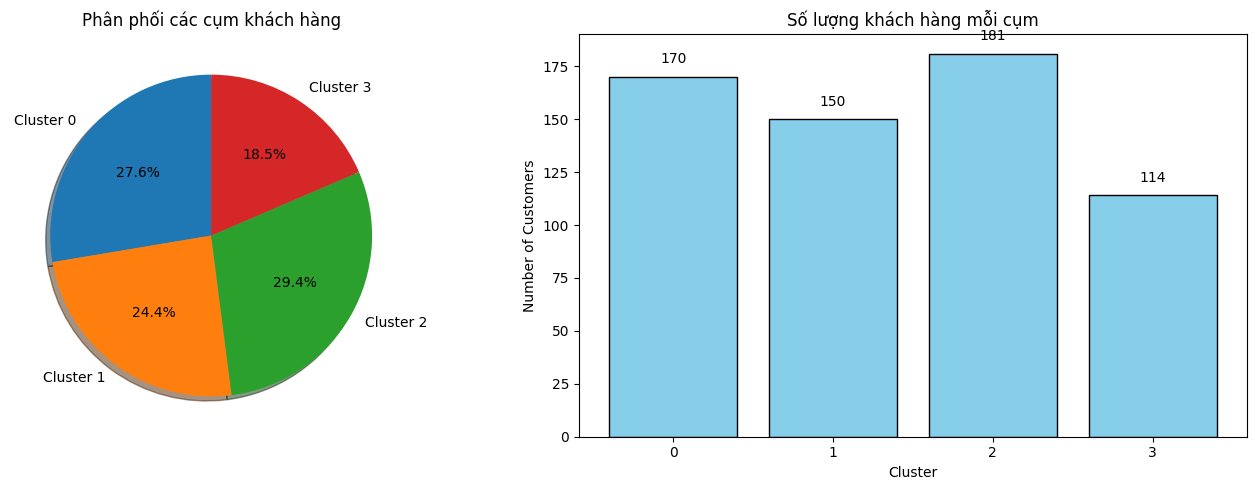

💾 Đã lưu kết quả phân cụm khách hàng


In [14]:
if X_customer_scaled is not None and 'optimal_k' in locals():
    print("\n" + "=" * 80)
    print("🔍 THỰC HIỆN K-MEANS CLUSTERING")
    print("=" * 80)
    
    # Thực hiện KMeans với k tối ưu
    kmeans = KMeans(
        n_clusters=optimal_k, 
        random_state=config.get('seed', 42),
        n_init=10,
        max_iter=300
    )
    
    customer_labels = kmeans.fit_predict(X_customer_scaled)
    
    # Thêm nhãn cụm vào customer_features
    customer_features['cluster'] = customer_labels
    
    print(f"✅ Đã phân {len(customer_features)} khách hàng vào {optimal_k} cụm")
    print(f"\n📊 Phân phối các cụm:")
    cluster_dist = customer_features['cluster'].value_counts().sort_index()
    for cluster, count in cluster_dist.items():
        print(f"   - Cụm {cluster}: {count} khách hàng ({count/len(customer_features)*100:.2f}%)")
    
    # Tính centroids
    centroids = pd.DataFrame(
        kmeans.cluster_centers_,
        columns=cluster_features
    )
    print(f"\n📊 Centroids của các cụm (scaled data):")
    display(centroids)
    
    # Vẽ biểu đồ phân phối các cụm
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    axes[0].pie(
        cluster_dist.values,
        labels=[f'Cluster {i}' for i in cluster_dist.index],
        autopct='%1.1f%%',
        startangle=90,
        shadow=True
    )
    axes[0].set_title('Phân phối các cụm khách hàng')
    
    # Bar chart
    axes[1].bar(cluster_dist.index, cluster_dist.values, color='skyblue', edgecolor='black')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Number of Customers')
    axes[1].set_title('Số lượng khách hàng mỗi cụm')
    axes[1].set_xticks(cluster_dist.index)
    
    # Thêm nhãn giá trị
    for i, (cluster, count) in enumerate(cluster_dist.items()):
        axes[1].text(cluster, count + 5, str(count), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/clustering_customer_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Lưu kết quả
    try:
        customer_features.to_parquet('../data/processed/customer_clusters.parquet', index=False)
        print("💾 Đã lưu kết quả phân cụm khách hàng")
    except Exception as e:
        print(f"⚠️ Không thể lưu parquet: {e}")
        customer_features.to_csv('../data/processed/customer_clusters.csv', index=False)
        print("💾 Đã lưu kết quả phân cụm dạng CSV")


📊 PHÂN TÍCH ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG

📊 Hồ sơ các cụm khách hàng:


,avg_order_value,recency_days,monetary_total,count,percentage
cluster,,,,,
0,163.2190,8.3118,242.6765,170,27.6400
1,362.4194,26.0533,443.6387,150,24.3900
2,336.1269,8.0718,722.6402,181,29.4300
3,126.0120,29.1667,157.7501,114,18.5400


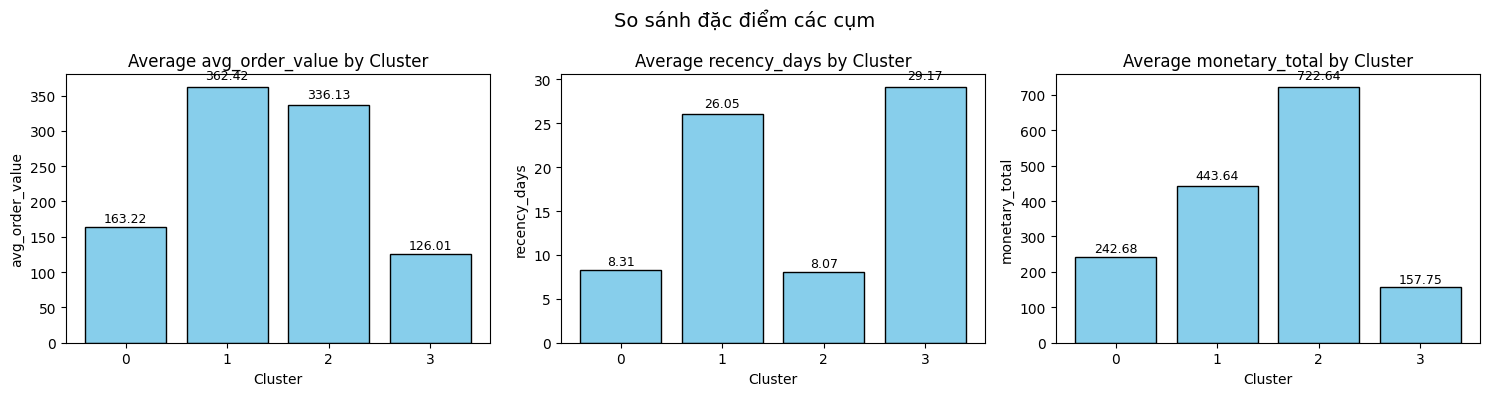

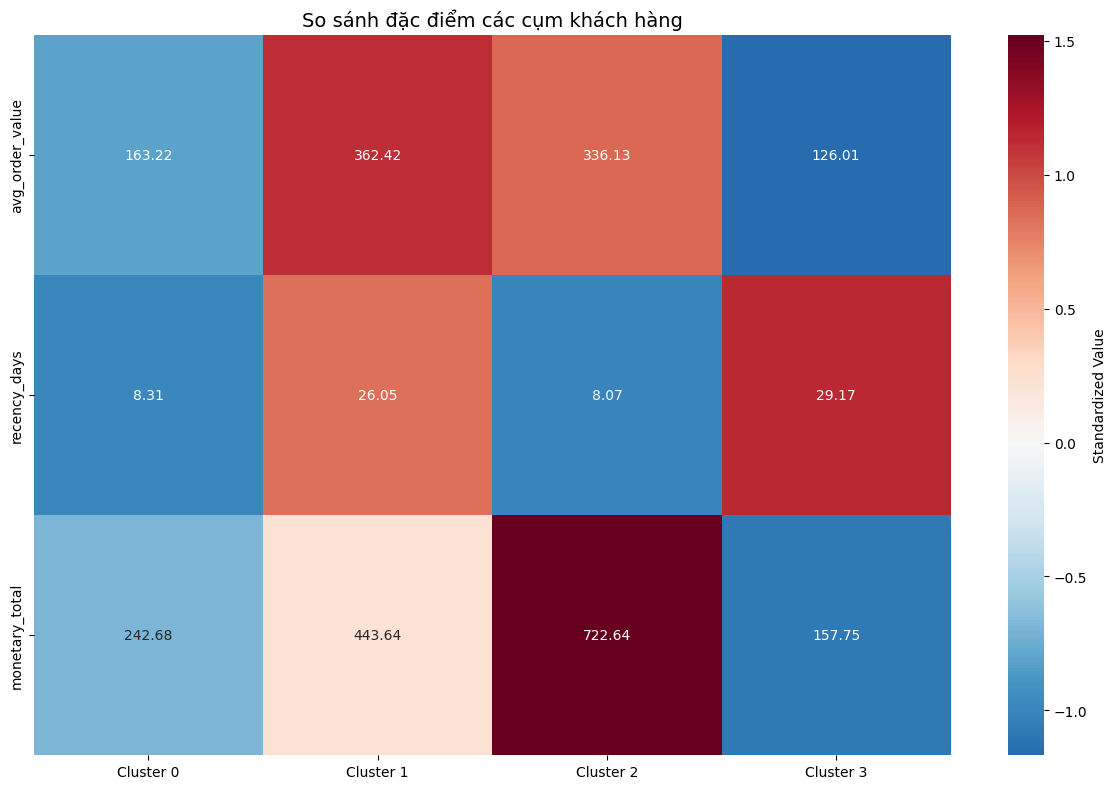

In [15]:
if 'customer_features' in locals() and 'cluster' in customer_features.columns:
    print("\n" + "=" * 80)
    print("📊 PHÂN TÍCH ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG")
    print("=" * 80)
    
    # Tính trung bình các features theo cụm
    cluster_profiles = customer_features.groupby('cluster')[cluster_features].mean().round(4)
    
    # Thêm thông tin về số lượng và tỷ lệ
    cluster_profiles['count'] = customer_features.groupby('cluster').size()
    cluster_profiles['percentage'] = (cluster_profiles['count'] / len(customer_features) * 100).round(2)
    
    print(f"\n📊 Hồ sơ các cụm khách hàng:")
    display(cluster_profiles)
    
    # Vẽ biểu đồ so sánh các cụm
    if len(cluster_features) > 0:
        n_features = len(cluster_features)
        n_cols = min(3, n_features)
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
        if n_rows > 1:
            axes = axes.flatten()
        elif n_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for i, feature in enumerate(cluster_features):
            if i < len(axes):
                # Lấy giá trị feature cho mỗi cụm
                feature_values = customer_features.groupby('cluster')[feature].mean()
                
                # Vẽ bar chart
                axes[i].bar(feature_values.index, feature_values.values, color='skyblue', edgecolor='black')
                axes[i].set_xlabel('Cluster')
                axes[i].set_ylabel(feature)
                axes[i].set_title(f'Average {feature} by Cluster')
                axes[i].set_xticks(feature_values.index)
                
                # Thêm nhãn giá trị
                for cluster, value in feature_values.items():
                    axes[i].text(cluster, value + value*0.02, f'{value:.2f}', ha='center', va='bottom', fontsize=9)
        
        # Ẩn các subplot thừa
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        
        plt.suptitle('So sánh đặc điểm các cụm', fontsize=14)
        plt.tight_layout()
        plt.savefig('../outputs/figures/clustering_customer_profiles.png', dpi=100, bbox_inches='tight')
        plt.show()
    
    # Heatmap để so sánh các cụm
    if len(cluster_features) > 0:
        plt.figure(figsize=(12, 8))
        
        # Chuẩn hóa dữ liệu để vẽ heatmap
        from sklearn.preprocessing import StandardScaler
        scaler_heatmap = StandardScaler()
        cluster_profiles_scaled = scaler_heatmap.fit_transform(cluster_profiles[cluster_features])
        
        sns.heatmap(
            cluster_profiles_scaled.T,
            annot=cluster_profiles[cluster_features].T.round(2),
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            xticklabels=[f'Cluster {i}' for i in cluster_profiles.index],
            yticklabels=cluster_features,
            cbar_kws={'label': 'Standardized Value'}
        )
        plt.title('So sánh đặc điểm các cụm khách hàng', fontsize=14)
        plt.tight_layout()
        plt.savefig('../outputs/figures/clustering_customer_heatmap.png', dpi=100, bbox_inches='tight')
        plt.show()

In [16]:
print("\n" + "=" * 80)
print("📦 CHUẨN BỊ DỮ LIỆU CHO PRODUCT CLUSTERING")
print("=" * 80)

product_config = config['clustering']['product_clustering']

if product_config['enabled'] and 'product_id' in df.columns:
    print(f"🛠️ Cấu hình phân cụm sản phẩm:")
    print(f"   - Features: {product_config['features']}")
    print(f"   - Scaling: {product_config['scaling']}")
    
    # Tính các features cho mỗi sản phẩm
    product_features = df.groupby('product_id').agg({
        'order_value': ['count', 'mean', 'sum'],
        'quantity': 'sum',
        target: ['mean', 'sum'] if target in df.columns else ['count']
    }).round(4)
    
    # Flatten column names
    product_features.columns = ['_'.join(col).strip() for col in product_features.columns.values]
    product_features = product_features.reset_index()
    
    # Rename columns
    product_features.rename(columns={
        'order_value_count': 'sold_count',
        'order_value_mean': 'avg_price',
        'order_value_sum': 'total_revenue',
        'quantity_sum': 'total_quantity'
    }, inplace=True)
    
    if target in df.columns:
        product_features.rename(columns={
            f'{target}_mean': 'product_return_rate',
            f'{target}_sum': 'return_count'
        }, inplace=True)
    
    # Thêm category nếu có
    if 'product_category' in df.columns:
        category_info = df.groupby('product_id')['product_category'].first().reset_index()
        product_features = product_features.merge(category_info, on='product_id')
    
    print(f"\n✅ Đã tạo features cho {len(product_features)} sản phẩm")
    print(f"\n📊 Các features:")
    display(product_features.head())
    
    # Chọn features cho clustering
    product_cluster_features = [col for col in product_config['features'] if col in product_features.columns]
    print(f"\n📌 Các features được chọn cho clustering: {product_cluster_features}")
    
    X_product = product_features[product_cluster_features].copy()
    
    # Xử lý missing
    X_product = X_product.fillna(X_product.mean())
    
    # Scaling
    if product_config['scaling'] == 'standard':
        scaler_prod = StandardScaler()
    else:
        scaler_prod = StandardScaler()
    
    X_product_scaled = scaler_prod.fit_transform(X_product)
    
    print(f"\n✅ Dữ liệu sau scaling: {X_product_scaled.shape}")
    
    # Lưu product features
    product_features.to_parquet('../data/processed/product_features.parquet', index=False)
    print("💾 Đã lưu product features")


📦 CHUẨN BỊ DỮ LIỆU CHO PRODUCT CLUSTERING
🛠️ Cấu hình phân cụm sản phẩm:
   - Features: ['product_return_rate', 'avg_price', 'return_count', 'sold_count']
   - Scaling: standard

✅ Đã tạo features cho 359 sản phẩm

📊 Các features:


,product_id,sold_count,avg_price,total_revenue,total_quantity,product_return_rate,return_count,product_category
0,100,5,362.3580,1811.7900,13,0.2000,1,Electronics
1,101,1,203.2900,203.2900,1,0.0000,0,Clothing
2,102,3,230.2833,690.8500,6,0.0000,0,Sports
3,103,4,305.7025,1222.8100,11,0.0000,0,Books
4,104,5,234.0940,1170.4700,10,0.2000,1,Electronics



📌 Các features được chọn cho clustering: ['product_return_rate', 'avg_price', 'return_count', 'sold_count']

✅ Dữ liệu sau scaling: (359, 4)
💾 Đã lưu product features


In [17]:
if 'cluster_profiles' in locals():
    print("\n" + "=" * 80)
    print("🏷️ ĐẶT TÊN VÀ DIỄN GIẢI CÁC CỤM KHÁCH HÀNG")
    print("=" * 80)
    
    cluster_names = {}
    cluster_descriptions = {}
    
    for cluster in cluster_profiles.index:
        profile = cluster_profiles.loc[cluster]
        
        print(f"\n🔍 CỤM {cluster}:")
        print(f"   - Số lượng: {profile['count']} KH ({profile['percentage']:.2f}%)")
        
        # Phân tích đặc điểm
        characteristics = []
        
        # Phân tích frequency
        if 'frequency' in profile:
            if profile['frequency'] > cluster_profiles['frequency'].quantile(0.75):
                characteristics.append("mua sắm thường xuyên")
                freq_desc = "cao"
            elif profile['frequency'] < cluster_profiles['frequency'].quantile(0.25):
                characteristics.append("mua sắm không thường xuyên")
                freq_desc = "thấp"
            else:
                characteristics.append("mua sắm trung bình")
                freq_desc = "trung bình"
            print(f"   - Tần suất: {freq_desc} ({profile['frequency']:.2f} orders)")
        
        # Phân tích monetary
        if 'monetary_total' in profile:
            if profile['monetary_total'] > cluster_profiles['monetary_total'].quantile(0.75):
                characteristics.append("chi tiêu cao")
                mon_desc = "cao"
            elif profile['monetary_total'] < cluster_profiles['monetary_total'].quantile(0.25):
                characteristics.append("chi tiêu thấp")
                mon_desc = "thấp"
            else:
                characteristics.append("chi tiêu trung bình")
                mon_desc = "trung bình"
            print(f"   - Chi tiêu: {mon_desc} (${profile['monetary_total']:.2f})")
        
        # Phân tích return rate
        if 'return_rate' in profile:
            if profile['return_rate'] > cluster_profiles['return_rate'].quantile(0.75):
                characteristics.append("rủi ro trả hàng cao")
                return_desc = "cao"
            elif profile['return_rate'] < cluster_profiles['return_rate'].quantile(0.25):
                characteristics.append("rủi ro trả hàng thấp")
                return_desc = "thấp"
            else:
                characteristics.append("rủi ro trả hàng trung bình")
                return_desc = "trung bình"
            print(f"   - Tỷ lệ trả hàng: {return_desc} ({profile['return_rate']*100:.2f}%)")
        
        # Phân tích recency
        if 'recency_days' in profile:
            if profile['recency_days'] > cluster_profiles['recency_days'].quantile(0.75):
                characteristics.append("khách hàng cũ")
                rec_desc = "cũ (lâu không mua)"
            elif profile['recency_days'] < cluster_profiles['recency_days'].quantile(0.25):
                characteristics.append("khách hàng mới")
                rec_desc = "mới (vừa mua gần đây)"
            else:
                characteristics.append("khách hàng trung thành")
                rec_desc = "trung bình"
            print(f"   - Độ mới: {rec_desc} ({profile['recency_days']:.0f} ngày)")
        
        # Đặt tên cho cụm dựa trên đặc điểm nổi bật
        if 'return_rate' in profile:
            if profile['return_rate'] > cluster_profiles['return_rate'].quantile(0.75):
                if profile['frequency'] > cluster_profiles['frequency'].quantile(0.75):
                    cluster_name = "Khách hàng VIP rủi ro cao"
                else:
                    cluster_name = "Khách hàng rủi ro cao"
            elif profile['return_rate'] < cluster_profiles['return_rate'].quantile(0.25):
                if 'monetary_total' in profile and profile['monetary_total'] > cluster_profiles['monetary_total'].quantile(0.75):
                    cluster_name = "Khách hàng VIP an toàn"
                else:
                    cluster_name = "Khách hàng an toàn"
            elif 'frequency' in profile and profile['frequency'] > cluster_profiles['frequency'].quantile(0.75):
                cluster_name = "Khách hàng thường xuyên"
            elif 'recency_days' in profile and profile['recency_days'] < cluster_profiles['recency_days'].quantile(0.25):
                cluster_name = "Khách hàng mới"
            else:
                cluster_name = f"Khách hàng {', '.join(characteristics)}" if characteristics else f"Cụm {cluster}"
        else:
            cluster_name = f"Cụm {cluster}"
        
        cluster_names[cluster] = cluster_name
        cluster_descriptions[cluster] = {
            'name': cluster_name,
            'size': int(profile['count']),
            'percentage': float(profile['percentage']),
            'characteristics': characteristics,
            'avg_return_rate': float(profile['return_rate']) if 'return_rate' in profile else None,
            'avg_frequency': float(profile['frequency']) if 'frequency' in profile else None,
            'avg_monetary': float(profile['monetary_total']) if 'monetary_total' in profile else None
        }
        
        print(f"\n   🏷️ Đặt tên: {cluster_name}")
    
    # Lưu cluster names và descriptions
    os.makedirs('../outputs/tables', exist_ok=True)
    with open('../outputs/tables/cluster_names.json', 'w', encoding='utf-8') as f:
        json.dump(cluster_descriptions, f, indent=2, ensure_ascii=False)
    
    print(f"\n💾 Đã lưu thông tin các cụm tại outputs/tables/cluster_names.json")
    
    # Vẽ biểu đồ tỷ lệ trả hàng theo cụm
    if 'return_rate' in cluster_profiles.columns:
        plt.figure(figsize=(10, 6))
        
        clusters = cluster_profiles.index
        return_rates = cluster_profiles['return_rate'].values * 100
        
        colors = ['red' if rate > cluster_profiles['return_rate'].quantile(0.75)*100 else 
                 'green' if rate < cluster_profiles['return_rate'].quantile(0.25)*100 else 
                 'orange' for rate in return_rates]
        
        bars = plt.bar(clusters, return_rates, color=colors, edgecolor='black')
        plt.xlabel('Cluster')
        plt.ylabel('Return Rate (%)')
        plt.title('Tỷ lệ trả hàng theo cụm khách hàng')
        plt.xticks(clusters, [cluster_names.get(c, f'Cluster {c}') for c in clusters], rotation=45, ha='right')
        
        # Thêm nhãn giá trị
        for bar, rate in zip(bars, return_rates):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    f'{rate:.2f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig('../outputs/figures/clustering_return_rate_by_cluster.png', dpi=100, bbox_inches='tight')
        plt.show()


🏷️ ĐẶT TÊN VÀ DIỄN GIẢI CÁC CỤM KHÁCH HÀNG

🔍 CỤM 0:
   - Số lượng: 170.0 KH (27.64%)
   - Chi tiêu: trung bình ($242.68)
   - Độ mới: trung bình (8 ngày)

   🏷️ Đặt tên: Cụm 0

🔍 CỤM 1:
   - Số lượng: 150.0 KH (24.39%)
   - Chi tiêu: trung bình ($443.64)
   - Độ mới: trung bình (26 ngày)

   🏷️ Đặt tên: Cụm 1

🔍 CỤM 2:
   - Số lượng: 181.0 KH (29.43%)
   - Chi tiêu: cao ($722.64)
   - Độ mới: mới (vừa mua gần đây) (8 ngày)

   🏷️ Đặt tên: Cụm 2

🔍 CỤM 3:
   - Số lượng: 114.0 KH (18.54%)
   - Chi tiêu: thấp ($157.75)
   - Độ mới: cũ (lâu không mua) (29 ngày)

   🏷️ Đặt tên: Cụm 3

💾 Đã lưu thông tin các cụm tại outputs/tables/cluster_names.json



📦 PHÂN CỤM SẢN PHẨM
🛠️ Cấu hình phân cụm sản phẩm:
   - Features: ['product_return_rate', 'avg_price', 'return_count', 'sold_count']
   - Scaling: standard

✅ Đã tạo features cho 359 sản phẩm

📊 Các features:


,product_id,sold_count,avg_price,total_revenue,total_quantity,product_return_rate,return_count,product_category
0,100,5,362.3580,1811.7900,13,0.2000,1,Electronics
1,101,1,203.2900,203.2900,1,0.0000,0,Clothing
2,102,3,230.2833,690.8500,6,0.0000,0,Sports
3,103,4,305.7025,1222.8100,11,0.0000,0,Books
4,104,5,234.0940,1170.4700,10,0.2000,1,Electronics



📌 Các features được chọn cho clustering: ['product_return_rate', 'avg_price', 'return_count', 'sold_count']

✅ Dữ liệu sau scaling: (359, 4)
💾 Đã lưu product features

✅ Đã phân 359 sản phẩm vào 4 cụm

📊 Phân phối các cụm sản phẩm:
   - Cụm 0: 91 sản phẩm (25.35%)
   - Cụm 1: 81 sản phẩm (22.56%)
   - Cụm 2: 130 sản phẩm (36.21%)
   - Cụm 3: 57 sản phẩm (15.88%)

📊 Centroids của các cụm sản phẩm:


,product_return_rate,avg_price,return_count,sold_count
0,-0.4337,1.0321,-0.4897,-0.4884
1,-0.2167,0.1995,0.0092,1.3970
2,-0.4337,-0.9035,-0.4897,-0.5347
3,1.9897,0.1296,1.8856,0.0140


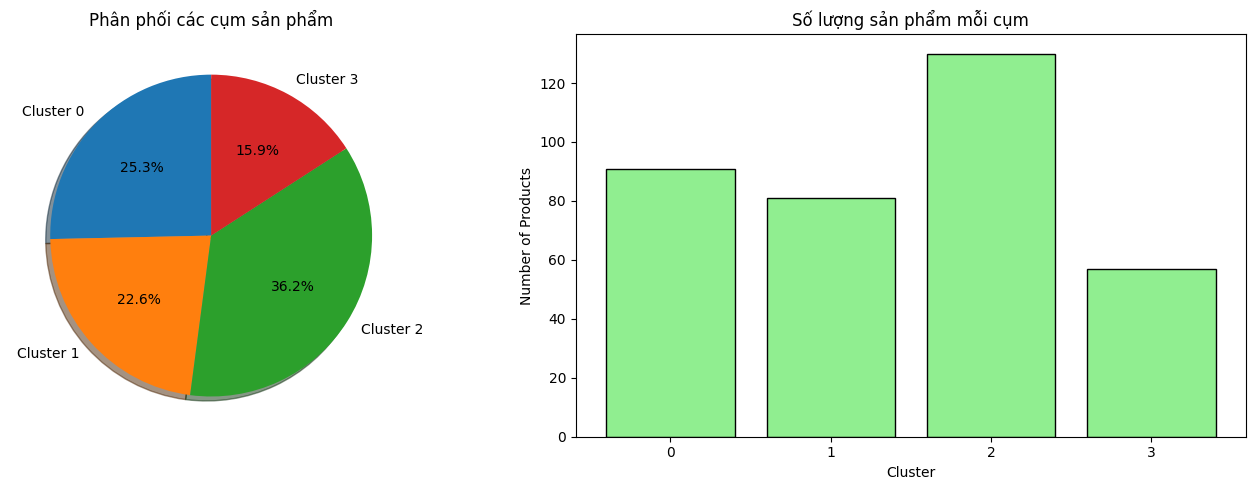

💾 Đã lưu kết quả phân cụm sản phẩm


In [18]:
print("\n" + "=" * 80)
print("📦 PHÂN CỤM SẢN PHẨM")
print("=" * 80)

product_config = config.get('clustering', {}).get('product_clustering', {})
if not product_config:
    product_config = {
        'enabled': True,
        'features': ['sold_count', 'avg_price', 'product_return_rate'],
        'scaling': 'standard',
        'methods': {
            'kmeans': {
                'n_clusters': 4
            }
        }
    }

if product_config.get('enabled', False) and 'product_id' in df.columns:
    print(f"🛠️ Cấu hình phân cụm sản phẩm:")
    print(f"   - Features: {product_config.get('features', [])}")
    print(f"   - Scaling: {product_config.get('scaling', 'standard')}")
    
    # Tính các features cho mỗi sản phẩm
    agg_dict = {
        'order_value': ['count', 'mean', 'sum'],
        'quantity': 'sum'
    }
    if target in df.columns:
        agg_dict[target] = ['mean', 'sum']
    
    product_features = df.groupby('product_id').agg(agg_dict).round(4)
    
    # Flatten column names
    product_features.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in product_features.columns.values]
    product_features = product_features.reset_index()
    
    # Rename columns
    rename_dict = {
        'order_value_count': 'sold_count',
        'order_value_mean': 'avg_price',
        'order_value_sum': 'total_revenue',
        'quantity_sum': 'total_quantity'
    }
    product_features.rename(columns=rename_dict, inplace=True)
    
    if target in df.columns:
        if f'{target}_mean' in product_features.columns:
            product_features.rename(columns={f'{target}_mean': 'product_return_rate'}, inplace=True)
        if f'{target}_sum' in product_features.columns:
            product_features.rename(columns={f'{target}_sum': 'return_count'}, inplace=True)
    
    # Thêm category nếu có
    if 'product_category' in df.columns:
        category_info = df.groupby('product_id')['product_category'].first().reset_index()
        product_features = product_features.merge(category_info, on='product_id', how='left')
    
    print(f"\n✅ Đã tạo features cho {len(product_features)} sản phẩm")
    print(f"\n📊 Các features:")
    display(product_features.head())
    
    # Chọn features cho clustering
    available_features = product_config.get('features', [])
    product_cluster_features = [col for col in available_features if col in product_features.columns]
    
    if not product_cluster_features:
        product_cluster_features = [col for col in ['sold_count', 'avg_price', 'product_return_rate'] 
                                   if col in product_features.columns]
    
    print(f"\n📌 Các features được chọn cho clustering: {product_cluster_features}")
    
    if len(product_cluster_features) >= 2:
        X_product = product_features[product_cluster_features].copy()
        
        # Xử lý missing
        X_product = X_product.fillna(X_product.mean())
        
        # Scaling
        scaler_prod = StandardScaler()
        X_product_scaled = scaler_prod.fit_transform(X_product)
        
        print(f"\n✅ Dữ liệu sau scaling: {X_product_scaled.shape}")
        
        # Lưu product features
        os.makedirs('../data/processed', exist_ok=True)
        try:
            product_features.to_parquet('../data/processed/product_features.parquet', index=False)
            print("💾 Đã lưu product features")
        except Exception as e:
            print(f"⚠️ Không thể lưu parquet: {e}")
            product_features.to_csv('../data/processed/product_features.csv', index=False)
            print("💾 Đã lưu product features dạng CSV")
        
        # Thực hiện KMeans
        n_clusters = product_config['methods']['kmeans'].get('n_clusters', 4)
        
        kmeans_prod = KMeans(
            n_clusters=n_clusters,
            random_state=config.get('seed', 42),
            n_init=10
        )
        
        product_labels = kmeans_prod.fit_predict(X_product_scaled)
        product_features['product_cluster'] = product_labels
        
        print(f"\n✅ Đã phân {len(product_features)} sản phẩm vào {n_clusters} cụm")
        
        # Phân phối các cụm
        prod_cluster_dist = product_features['product_cluster'].value_counts().sort_index()
        print(f"\n📊 Phân phối các cụm sản phẩm:")
        for cluster, count in prod_cluster_dist.items():
            print(f"   - Cụm {cluster}: {count} sản phẩm ({count/len(product_features)*100:.2f}%)")
        
        # Tính centroids
        prod_centroids = pd.DataFrame(
            kmeans_prod.cluster_centers_,
            columns=product_cluster_features
        )
        print(f"\n📊 Centroids của các cụm sản phẩm:")
        display(prod_centroids)
        
        # Vẽ biểu đồ
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Pie chart
        axes[0].pie(
            prod_cluster_dist.values,
            labels=[f'Cluster {i}' for i in prod_cluster_dist.index],
            autopct='%1.1f%%',
            startangle=90,
            shadow=True
        )
        axes[0].set_title('Phân phối các cụm sản phẩm')
        
        # Bar chart
        axes[1].bar(prod_cluster_dist.index, prod_cluster_dist.values, color='lightgreen', edgecolor='black')
        axes[1].set_xlabel('Cluster')
        axes[1].set_ylabel('Number of Products')
        axes[1].set_title('Số lượng sản phẩm mỗi cụm')
        axes[1].set_xticks(prod_cluster_dist.index)
        
        plt.tight_layout()
        plt.savefig('../outputs/figures/clustering_product_distribution.png', dpi=100, bbox_inches='tight')
        plt.show()
        
        # Lưu kết quả
        try:
            product_features.to_parquet('../data/processed/product_clusters.parquet', index=False)
            print("💾 Đã lưu kết quả phân cụm sản phẩm")
        except Exception as e:
            print(f"⚠️ Không thể lưu parquet: {e}")
            product_features.to_csv('../data/processed/product_clusters.csv', index=False)
            print("💾 Đã lưu kết quả phân cụm dạng CSV")
    else:
        print("⚠️ Không đủ features để phân cụm sản phẩm")
else:
    print("⚠️ Product clustering không được enabled hoặc không có product_id")

In [19]:
print("\n" + "=" * 80)
print("💡 TỔNG HỢP INSIGHTS TỪ MINING VÀ CLUSTERING")
print("=" * 80)

all_insights = []

# 1. Insights từ Association Rules
if 'insights' in locals() and insights:
    all_insights.extend(insights)

# 2. Insights từ Customer Clustering
if 'cluster_descriptions' in locals() and cluster_descriptions:
    customer_insight = {
        'type': 'CUSTOMER_CLUSTERING',
        'title': 'Phân khúc khách hàng theo hành vi',
        'details': []
    }
    
    for cluster_id, desc in cluster_descriptions.items():
        detail = f"Cụm {cluster_id} - {desc['name']}: {desc['size']} KH ({desc['percentage']:.2f}%)"
        if desc.get('avg_return_rate'):
            detail += f", tỷ lệ trả hàng {desc['avg_return_rate']*100:.2f}%"
        customer_insight['details'].append(detail)
        print(f"👥 {detail}")
    
    all_insights.append(customer_insight)

# 3. Insights từ Product Clustering
if 'product_features' in locals() and 'product_cluster' in product_features.columns:
    product_insight = {
        'type': 'PRODUCT_CLUSTERING',
        'title': 'Phân khúc sản phẩm',
        'details': []
    }
    
    prod_summary = product_features.groupby('product_cluster').agg({
        'product_id': 'count',
        'product_return_rate': 'mean' if 'product_return_rate' in product_features.columns else None
    }).round(4)
    
    prod_summary.columns = ['count', 'avg_return_rate']
    
    for cluster in prod_summary.index:
        detail = f"Cụm {cluster}: {prod_summary.loc[cluster, 'count']} SP"
        if 'avg_return_rate' in prod_summary.columns:
            detail += f", tỷ lệ trả TB {prod_summary.loc[cluster, 'avg_return_rate']*100:.2f}%"
        product_insight['details'].append(detail)
        print(f"📦 {detail}")
    
    all_insights.append(product_insight)

# 4. Khuyến nghị hành động
recommendations = {
    'type': 'RECOMMENDATIONS',
    'title': 'Khuyến nghị hành động dựa trên kết quả khai phá',
    'details': [
        "1. Đối với khách hàng rủi ro cao: Áp dụng chính sách kiểm tra đơn hàng chặt chẽ hơn",
        "2. Đối với sản phẩm rủi ro cao: Xem xét cải tiến chất lượng, bổ sung mô tả chi tiết",
        "3. Tối ưu hóa chính sách khuyến mãi dựa trên các luật kết hợp đã phát hiện",
        "4. Xây dựng mô hình dự đoán trả hàng cho từng phân khúc khách hàng"
    ]
}

all_insights.append(recommendations)

print("\n📋 KHUYẾN NGHỊ HÀNH ĐỘNG:")
for rec in recommendations['details']:
    print(f"   {rec}")

# Lưu tất cả insights
os.makedirs('../outputs/tables', exist_ok=True)
with open('../outputs/tables/all_mining_insights.json', 'w', encoding='utf-8') as f:
    json.dump(all_insights, f, indent=2, ensure_ascii=False)

print(f"\n💾 Đã lưu {len(all_insights)} insights tại outputs/tables/all_mining_insights.json")


💡 TỔNG HỢP INSIGHTS TỪ MINING VÀ CLUSTERING
👥 Cụm 0 - Cụm 0: 170 KH (27.64%)
👥 Cụm 1 - Cụm 1: 150 KH (24.39%)
👥 Cụm 2 - Cụm 2: 181 KH (29.43%)
👥 Cụm 3 - Cụm 3: 114 KH (18.54%)
📦 Cụm 0: 91 SP, tỷ lệ trả TB 0.00%
📦 Cụm 1: 81 SP, tỷ lệ trả TB 4.43%
📦 Cụm 2: 130 SP, tỷ lệ trả TB 0.00%
📦 Cụm 3: 57 SP, tỷ lệ trả TB 49.53%

📋 KHUYẾN NGHỊ HÀNH ĐỘNG:
   1. Đối với khách hàng rủi ro cao: Áp dụng chính sách kiểm tra đơn hàng chặt chẽ hơn
   2. Đối với sản phẩm rủi ro cao: Xem xét cải tiến chất lượng, bổ sung mô tả chi tiết
   3. Tối ưu hóa chính sách khuyến mãi dựa trên các luật kết hợp đã phát hiện
   4. Xây dựng mô hình dự đoán trả hàng cho từng phân khúc khách hàng

💾 Đã lưu 4 insights tại outputs/tables/all_mining_insights.json


In [20]:
print("\n" + "=" * 80)
print("✅ KẾT LUẬN VÀ CHUẨN BỊ CHO BƯỚC TIẾP THEO")
print("=" * 80)

# Tổng kết
print("\n📊 TỔNG KẾT KẾT QUẢ KHAI PHÁ:")

if 'rules' in locals() and isinstance(rules, pd.DataFrame) and not rules.empty:
    print(f"   - Số luật kết hợp phát hiện: {len(rules)}")
    if 'return_rules' in locals():
        print(f"   - Số luật liên quan đến Return: {len(return_rules)}")

if 'customer_features' in locals() and 'cluster' in customer_features.columns:
    print(f"   - Số cụm khách hàng: {customer_features['cluster'].nunique()}")
    print(f"   - Đã phân tích đặc điểm {len(customer_features)} khách hàng")

if 'product_features' in locals() and 'product_cluster' in product_features.columns:
    print(f"   - Số cụm sản phẩm: {product_features['product_cluster'].nunique()}")
    print(f"   - Đã phân tích đặc điểm {len(product_features)} sản phẩm")

# Các file đã tạo
print("\n📁 CÁC FILE ĐÃ TẠO:")
if os.path.exists('../data/processed/basket_format.parquet'):
    print("   - data/processed/basket_format.parquet")
if os.path.exists('../data/processed/frequent_itemsets.parquet'):
    print("   - data/processed/frequent_itemsets.parquet")
if os.path.exists('../data/processed/association_rules.parquet'):
    print("   - data/processed/association_rules.parquet")
if os.path.exists('../data/processed/customer_features.parquet'):
    print("   - data/processed/customer_features.parquet")
if os.path.exists('../data/processed/customer_clusters.parquet'):
    print("   - data/processed/customer_clusters.parquet")
if os.path.exists('../data/processed/product_features.parquet'):
    print("   - data/processed/product_features.parquet")
if os.path.exists('../data/processed/product_clusters.parquet'):
    print("   - data/processed/product_clusters.parquet")
print("   - outputs/figures/mining_*.png")
print("   - outputs/tables/*_insights.json")

print("\n🎉 HOÀN THÀNH KHAI PHÁ LUẬT KẾT HỢP VÀ PHÂN CỤM!")
print("\n✅ Sẵn sàng chuyển sang notebook 04_modeling_supervised.ipynb")


✅ KẾT LUẬN VÀ CHUẨN BỊ CHO BƯỚC TIẾP THEO

📊 TỔNG KẾT KẾT QUẢ KHAI PHÁ:
   - Số luật kết hợp phát hiện: 64
   - Số luật liên quan đến Return: 0
   - Số cụm khách hàng: 4
   - Đã phân tích đặc điểm 615 khách hàng
   - Số cụm sản phẩm: 4
   - Đã phân tích đặc điểm 359 sản phẩm

📁 CÁC FILE ĐÃ TẠO:
   - data/processed/basket_format.parquet
   - data/processed/customer_features.parquet
   - data/processed/customer_clusters.parquet
   - data/processed/product_features.parquet
   - data/processed/product_clusters.parquet
   - outputs/figures/mining_*.png
   - outputs/tables/*_insights.json

🎉 HOÀN THÀNH KHAI PHÁ LUẬT KẾT HỢP VÀ PHÂN CỤM!

✅ Sẵn sàng chuyển sang notebook 04_modeling_supervised.ipynb
